# 02. 전처리 및 피처 엔지니어링

## STEP 0. 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 로드 완료')

라이브러리 로드 완료


## STEP 1. 데이터 로드 및 KR 필터링 (약 2~3분 소요)

In [2]:
import csv

kr_rows = []
filepath = '/Users/eunseoklee/Downloads/ml/trending_yt_videos_113_countries.csv'

with open(filepath, encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if row['country'] == 'KR':
            kr_rows.append(row)

df_raw = pd.DataFrame(kr_rows)
print(f'KR 원본 행 수: {len(df_raw):,}')
df_raw.head()

KR 원본 행 수: 48,341


,title,channel_name,daily_rank,daily_movement,weekly_movement,snapshot_date,country,view_count,like_count,comment_count,description,thumbnail_url,video_id,channel_id,video_tags,kind,publish_date,langauge
0,Smile For You,ISEGYE IDOL - Topic,1,49,49,2026-06-20,KR,35209,2581,131,Provided to YouTube by GENIE MUSIC\n\nSmile Fo...,https://i.ytimg.com/vi/IJcbS_dQABk/mqdefault.jpg,IJcbS_dQABk,UChQveKKV7nZHLSGJaAKOkHA,"ISEGYE IDOL, 이세계아이돌, Smile For You",youtube#video,2026-06-19 00:00:00+00:00,ko
1,진짜 떴습니다. ≪스파이더맨: 브랜드뉴데이≫ 메인 예고편 리뷰 & 떡밥 나노 분석 총정리,무비띵크_Movie Think,2,0,48,2026-06-20,KR,624983,9668,1159,#스파이더맨브랜드뉴데이 #스파이더맨 #브랜드뉴데이\n🎬 진짜 떴습니다. ≪스파이더맨...,https://i.ytimg.com/vi/SV7EDrgTmPw/mqdefault.jpg,SV7EDrgTmPw,UCKBzr20577Xcn0LJoRVES_A,"영화리뷰, 영화추천, 무비띵크, 마블, 마블영화, 마블유튜브, 마블유튜버, 마블띵크...",youtube#video,2026-06-18 00:00:00+00:00,ko
2,다딱이 감독관,랄로,3,0,47,2026-06-20,KR,694748,5072,670,랄로 풀코스 youtube.com/@랄롱\n치지직 생방송 https://naver....,https://i.ytimg.com/vi/HLSQWGqAW0Y/mqdefault.jpg,HLSQWGqAW0Y,UCD2YO_A_PVMgMDN9jpRrpVA,"랄로, 랄튜브, 김찬호",youtube#video,2026-06-18 00:00:00+00:00,ko
3,Fast Cars & Superstars,Cristian Marchi - Topic,4,6,46,2026-06-20,KR,110227,1327,0,Provided to YouTube by Universal Music Group\n...,https://i.ytimg.com/vi/l26KDHTABxw/mqdefault.jpg,l26KDHTABxw,UCfc-IfX9K_qr9jBF5lFA9-w,"Cristian Marchi, Reverend Haus, Fast Cars & Su...",youtube#video,2026-06-18 00:00:00+00:00,en
4,[스파이더맨: 브랜드 뉴 데이] 메인 예고편,소니픽쳐스코리아,5,0,45,2026-06-20,KR,1497359,19698,3050,모두가 그를 잊었지만\n세상은 그가 필요하다\n\n[스파이더맨: 브랜드 뉴 데이] ...,https://i.ytimg.com/vi/dosbhD_1LIo/mqdefault.jpg,dosbhD_1LIo,UCY2wHBgv2W30w6lqoLxq99g,,youtube#video,2026-06-17 00:00:00+00:00,en


## STEP 2. 데이터 타입 변환

In [3]:
df = df_raw.copy()

for col in ['view_count','like_count','comment_count','daily_rank','daily_movement','weekly_movement']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['snapshot_date'] = pd.to_datetime(df['snapshot_date'])
df['publish_date']  = pd.to_datetime(df['publish_date'], utc=True).dt.tz_localize(None)

print('=== 결측치 현황 ===')
print(df.isnull().sum())

=== 결측치 현황 ===
title              0
channel_name       0
daily_rank         0
daily_movement     0
weekly_movement    0
snapshot_date      0
country            0
view_count         0
like_count         0
comment_count      0
description        0
thumbnail_url      0
video_id           0
channel_id         0
video_tags         0
kind               0
publish_date       0
langauge           0
dtype: int64


## STEP 3. 영상별 집계 (중복 제거)

In [4]:
agg = df.groupby('video_id').agg(
    title         = ('title', 'first'),
    channel_name  = ('channel_name', 'first'),
    view_count    = ('view_count', 'max'),
    like_count    = ('like_count', 'max'),
    comment_count = ('comment_count', 'max'),
    best_rank     = ('daily_rank', 'min'),
    trending_days = ('snapshot_date', 'nunique'),
    first_trend   = ('snapshot_date', 'min'),
    publish_date  = ('publish_date', 'first'),
    video_tags    = ('video_tags', 'first'),
    language      = ('langauge', 'first'),
).reset_index()

print(f'고유 영상 수: {len(agg):,}')
agg.head(3)

고유 영상 수: 19,129


,video_id,title,channel_name,view_count,like_count,comment_count,best_rank,trending_days,first_trend,publish_date,video_tags,language
0,--b0x4XO6_g,"붉은사막 플레이 약 30시간 째, 중간 소감입니다",중년게이머 김실장,172407,3506,1290,17,1,2026-03-27,2026-03-26,,ko
1,-03OtM9D-fU,멕시코 vs 대한민국 - FIFA 월드컵 2026 | 조별리그 | 손흥민 vs 멕시...,Alone Gaming,100509,1604,101,20,1,2026-06-19,2026-06-18,"멕시코, 대한민국, 손흥민, FIFA 월드컵 2026, 조별리그, 멕시코 대한민국 ...",ko
2,-0ICh3CmHVs,[EN/JP] [#WSWF/3회 선공개] 리더 계급 메인 댄서? 뺏어줄게!,The CHOOM (더 춤),1369114,15734,3860,3,3,2025-06-08,2025-06-07,"Dance, Mnet, SWF, SWF3, WorldofSWF, 댄스, 스우파, 스...",en-US


## STEP 4. 파생 변수(Feature Engineering) 생성

In [5]:
agg['title_length']   = agg['title'].str.len()
agg['tag_count']      = agg['video_tags'].apply(
    lambda x: 0 if (pd.isna(x) or x.strip() == '') else len(x.split('|'))
)
agg['like_ratio']     = agg['like_count'] / (agg['view_count'] + 1)
agg['comment_ratio']  = agg['comment_count'] / (agg['view_count'] + 1)
agg['days_to_trend']  = (agg['first_trend'] - agg['publish_date']).dt.days.clip(lower=0)
agg['publish_weekday']= agg['publish_date'].dt.weekday
agg['publish_hour']   = agg['publish_date'].dt.hour
agg['is_korean']      = agg['language'].apply(lambda x: 1 if str(x).startswith('ko') else 0)

channel_avg = agg.groupby('channel_name')['view_count'].mean()
agg['log_channel_avg'] = np.log1p(agg['channel_name'].map(channel_avg))

print('파생 변수 생성 완료')
agg[['title_length','tag_count','like_ratio','comment_ratio',
     'days_to_trend','trending_days','log_channel_avg']].describe().round(3)

파생 변수 생성 완료


,title_length,tag_count,like_ratio,comment_ratio,days_to_trend,trending_days,log_channel_avg
count,19129.000,19129.000,19129.000,19129.000,19129.000,19129.000,19129.000
mean,38.489,0.844,0.072,0.009,1.458,2.527,12.750
std,22.465,0.368,6.334,0.846,1.649,1.728,1.226
min,1.000,0.000,0.000,0.000,0.000,1.000,8.129
25%,21.000,1.000,0.009,0.001,1.000,1.000,11.948
50%,35.000,1.000,0.016,0.001,1.000,2.000,12.643
75%,52.000,1.000,0.029,0.003,2.000,4.000,13.437
max,100.000,5.000,876.000,117.000,30.000,12.000,18.568


## STEP 5. 종속변수 생성 — 조회수 3분위 구간 (상/중/하)

하(0): ~ 160,532회
중(1): 160,532 ~ 435,009회
상(2): 435,009회 ~
view_class
상(2)    6377
하(0)    6376
중(1)    6376
Name: count, dtype: int64


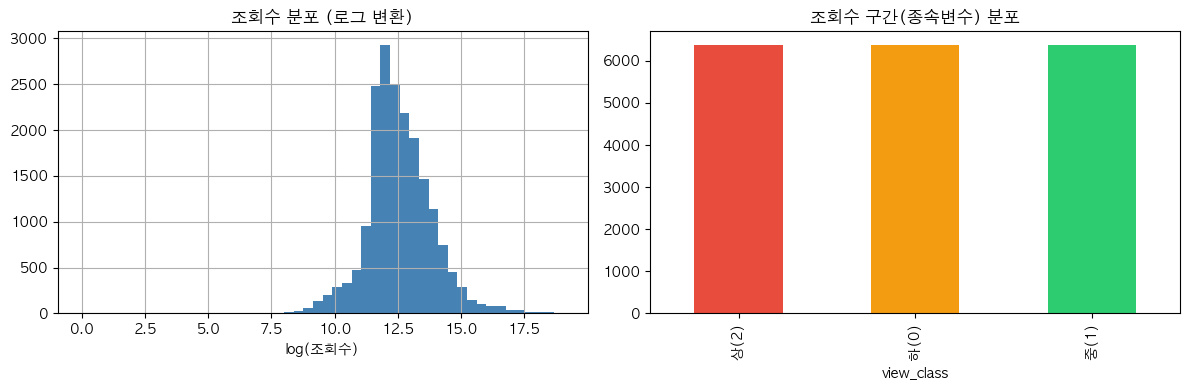

In [ ]:
df_ml = agg.dropna(subset=['view_count','like_count','comment_count',
                            'days_to_trend','publish_weekday','publish_hour']).copy()

df_ml['view_class'], bins = pd.qcut(df_ml['view_count'], q=3,
                                     labels=['하(0)','중(1)','상(2)'], retbins=True)
print(f'하(0): ~ {bins[1]:,.0f}회')
print(f'중(1): {bins[1]:,.0f} ~ {bins[2]:,.0f}회')
print(f'상(2): {bins[2]:,.0f}회 ~')
print(df_ml['view_class'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_ml['view_count'].apply(np.log1p).hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('조회수 분포 (로그 변환)')
axes[0].set_xlabel('log(조회수)')
df_ml['view_class'].value_counts().plot(kind='bar', ax=axes[1], color=['#e74c3c','#f39c12','#2ecc71'])
axes[1].set_title('조회수 구간(종속변수) 분포')
plt.tight_layout()
plt.show()

## STEP 12. 데이터 프로파일링 리포트

In [17]:
print('=== 데이터 상단부 샘플 ===')
display(df_ml[['title','view_count','like_count','comment_count',
               'title_length','tag_count','trending_days','view_class']].head(5))

print('\n=== 데이터 하단부 샘플 ===')
display(df_ml[['title','view_count','like_count','comment_count',
               'title_length','tag_count','trending_days','view_class']].tail(5))

print('\n=== 주요 변수 기술 통계 ===')
display(df_ml[FEATURES + ['view_count']].describe().round(2))

=== 데이터 상단부 샘플 ===


,title,view_count,like_count,comment_count,title_length,tag_count,trending_days,view_class
0,"붉은사막 플레이 약 30시간 째, 중간 소감입니다",172407,3506,1290,27,0,1,중(1)
1,멕시코 vs 대한민국 - FIFA 월드컵 2026 | 조별리그 | 손흥민 vs 멕시...,100509,1604,101,59,1,1,하(0)
2,[EN/JP] [#WSWF/3회 선공개] 리더 계급 메인 댄서? 뺏어줄게!,1369114,15734,3860,41,1,3,상(2)
3,아 늙기 싫다..【SLL EP.01】,209563,4000,425,20,1,2,중(1)
4,사마귀 | 공식 예고편 | 넷플릭스,144124,1362,295,19,1,1,하(0)



=== 데이터 하단부 샘플 ===


,title,view_count,like_count,comment_count,title_length,tag_count,trending_days,view_class
19124,롤이.. 조금.. 아픕니다...,259825,1755,1118,17,1,1,중(1)
19125,King Gnu - AIZO,2551743,113817,5271,15,1,2,상(2)
19126,지민 (Jimin) 'Closer Than This' Official MV,8646198,1507690,116447,41,1,6,상(2)
19127,교배 아저씨의 X스 노트 [다피스 ep.4],123786,956,82,24,1,1,하(0)
19128,"""내가 정글해도 이상호 이길 듯?"" 여기서 지면 진짜 평생 놀림감이다..! 이상호 ...",219709,1417,257,63,1,1,중(1)



=== 주요 변수 기술 통계 ===


,title_length,tag_count,like_ratio,comment_ratio,days_to_trend,trending_days,publish_weekday,publish_hour,is_korean,view_count
count,19129.00,19129.00,19129.00,19129.00,19129.00,19129.00,19129.00,19129.0,19129.00,19129.0
mean,38.49,0.84,0.07,0.01,1.46,2.53,2.94,0.0,0.77,999517.0
std,22.46,0.37,6.33,0.85,1.65,1.73,1.99,0.2,0.42,5394070.7
min,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.0,0.00,0.0
25%,21.00,1.00,0.01,0.00,1.00,1.00,1.00,0.0,1.00,131572.0
50%,35.00,1.00,0.02,0.00,1.00,2.00,3.00,0.0,1.00,251417.0
75%,52.00,1.00,0.03,0.00,2.00,4.00,5.00,0.0,1.00,597733.0
max,100.00,5.00,876.00,117.00,30.00,12.00,6.00,22.0,1.00,187042280.0


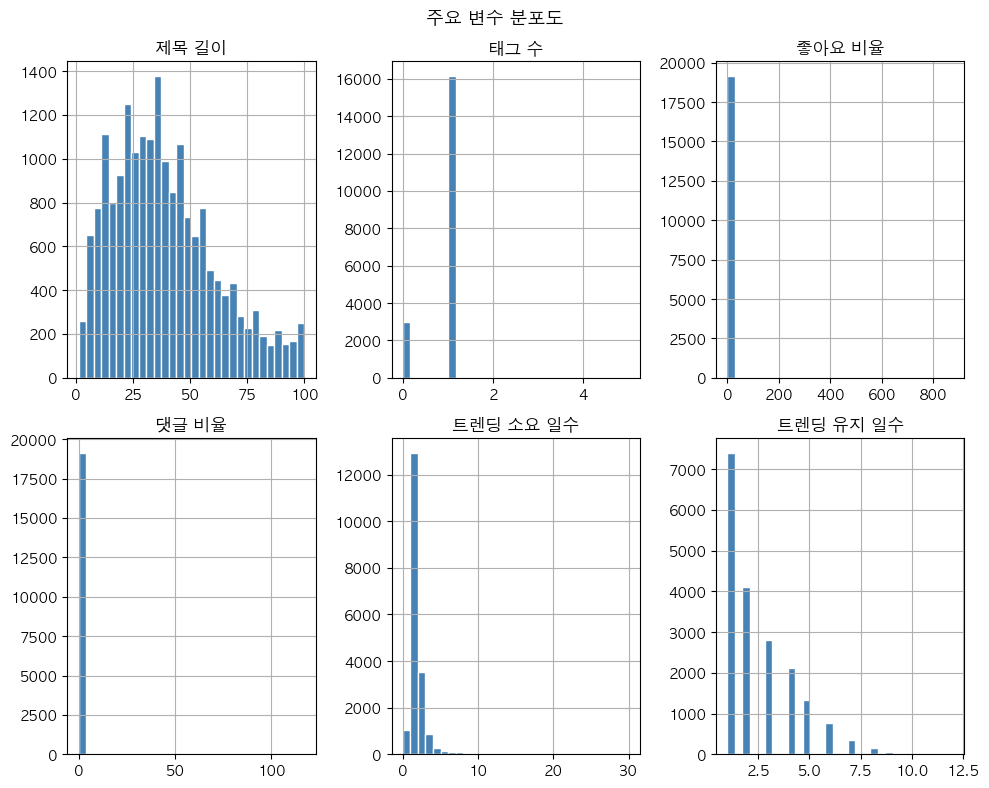

모든 그래프 저장 완료!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()
plot_cols = [
    ('title_length','제목 길이'), ('tag_count','태그 수'),
    ('like_ratio','좋아요 비율'), ('comment_ratio','댓글 비율'),
    ('days_to_trend','트렌딩 소요 일수'), ('trending_days','트렌딩 유지 일수'),
]
for ax, (col, label) in zip(axes, plot_cols):
    df_ml[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(label)
plt.suptitle('주요 변수 분포도', fontsize=13)
plt.tight_layout()
plt.show()
print('모든 그래프 저장 완료!')